# Module ❶: Tăng trưởng & Tài chính - Descriptive Analysis
**Task 2.1: Revenue YoY Trend & Seasonality**
*Owner: Lê Bảo Khánh*

Mục tiêu:
- Phân tích xu hướng doanh thu qua các năm (2012-2022).
- Tính toán tốc độ tăng trưởng (YoY Growth Rate) và CAGR.
- Phát hiện tính mùa vụ (Seasonality) theo tháng/quý.

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
import os

# Add src to path if needed
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from data_loader import DataLoader

# Set random state and plot style
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

Matplotlib is building the font cache; this may take a moment.


In [3]:
# 1. Load data: sales, order_items, products
loader = DataLoader()

# Load necessary tables
sales = loader.load("sales")
order_items = loader.load("order_items")
products = loader.load("products")

print("Sales data shape:", sales.shape)
print("Date range:", sales['Date'].min(), "to", sales['Date'].max())
print(sales.head(3))

Sales data shape: (3833, 3)
Date range: 2012-07-04 to 2022-12-31
shape: (3, 3)
┌────────────┬──────────┬──────────┐
│ Date       ┆ Revenue  ┆ COGS     │
│ ---        ┆ ---      ┆ ---      │
│ date       ┆ f64      ┆ f64      │
╞════════════╪══════════╪══════════╡
│ 2012-07-04 ┆ 5.1235e6 ┆ 3.9830e6 │
│ 2012-07-05 ┆ 2.7518e6 ┆ 2.1506e6 │
│ 2012-07-06 ┆ 3.0540e6 ┆ 2.5176e6 │
└────────────┴──────────┴──────────┘


## 1. Xu hướng Doanh thu (Revenue YoY Trend)
Phân tích tổng doanh thu theo năm và tốc độ tăng trưởng (Growth Rate).

In [4]:
# Thêm cột Year và Month
sales = sales.with_columns([
    pl.col("Date").dt.year().alias("Year"),
    pl.col("Date").dt.month().alias("Month"),
    pl.col("Date").dt.quarter().alias("Quarter")
])

# Group by Year
yearly_sales = sales.group_by("Year").agg(
    pl.col("Revenue").sum().alias("Total_Revenue")
).sort("Year")

# Tính Growth Rate
yearly_sales = yearly_sales.with_columns([
    (pl.col("Total_Revenue").diff() / pl.col("Total_Revenue").shift(1) * 100).alias("YoY_Growth_Rate_%")
])

print(yearly_sales)

shape: (11, 3)
┌──────┬───────────────┬───────────────────┐
│ Year ┆ Total_Revenue ┆ YoY_Growth_Rate_% │
│ ---  ┆ ---           ┆ ---               │
│ i32  ┆ f64           ┆ f64               │
╞══════╪═══════════════╪═══════════════════╡
│ 2012 ┆ 7.4150e8      ┆ null              │
│ 2013 ┆ 1.6572e9      ┆ 123.489474        │
│ 2014 ┆ 1.8718e9      ┆ 12.954407         │
│ 2015 ┆ 1.8899e9      ┆ 0.966316          │
│ 2016 ┆ 2.1046e9      ┆ 11.360549         │
│ …    ┆ …             ┆ …                 │
│ 2018 ┆ 1.8501e9      ┆ -3.193962         │
│ 2019 ┆ 1.1368e9      ┆ -38.555341        │
│ 2020 ┆ 1.0545e9      ┆ -7.238668         │
│ 2021 ┆ 1.0430e9      ┆ -1.087929         │
│ 2022 ┆ 1.1697e9      ┆ 12.148051         │
└──────┴───────────────┴───────────────────┘


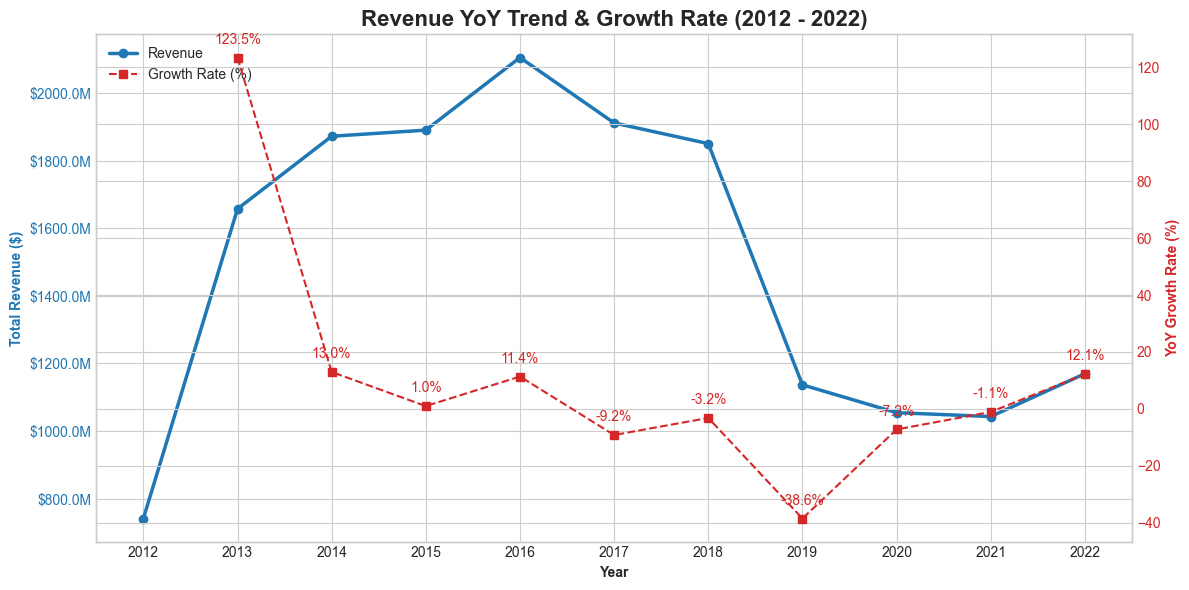

In [5]:
# Vẽ Line Chart YoY
fig, ax1 = plt.subplots(figsize=(12, 6))

years = yearly_sales["Year"].to_list()
revenue = yearly_sales["Total_Revenue"].to_list()
growth = yearly_sales["YoY_Growth_Rate_%"].to_list()

color = 'tab:blue'
ax1.set_xlabel('Year', fontweight='bold')
ax1.set_ylabel('Total Revenue ($)', color=color, fontweight='bold')
line1 = ax1.plot(years, revenue, marker='o', linewidth=2.5, color=color, label='Revenue')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(years)

# Format y-axis to millions
formatter = plt.FuncFormatter(lambda x, pos: f'${x*1e-6:.1f}M')
ax1.yaxis.set_major_formatter(formatter)

# Dual axis for Growth Rate
ax2 = ax1.twinx()  
color2 = 'tab:red'
ax2.set_ylabel('YoY Growth Rate (%)', color=color2, fontweight='bold')
line2 = ax2.plot(years, growth, marker='s', linestyle='--', color=color2, label='Growth Rate (%)')
ax2.tick_params(axis='y', labelcolor=color2)

# Annotate anomalies/key points
for i, txt in enumerate(growth):
    if txt is not None and not np.isnan(txt):
        ax2.annotate(f"{txt:.1f}%", (years[i], growth[i]), textcoords="offset points", xytext=(0,10), ha='center', color=color2)

plt.title('Revenue YoY Trend & Growth Rate (2012 - 2022)', fontsize=16, fontweight='bold')
fig.tight_layout()

# Legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.show()

In [6]:
# Tính CAGR (Compound Annual Growth Rate) toàn giai đoạn
# CAGR = (Ending Value / Beginning Value) ^ (1 / Number of Years) - 1

start_year = yearly_sales["Year"][0]
end_year = yearly_sales["Year"][-1]
num_years = end_year - start_year

start_revenue = yearly_sales.filter(pl.col("Year") == start_year)["Total_Revenue"][0]
end_revenue = yearly_sales.filter(pl.col("Year") == end_year)["Total_Revenue"][0]

cagr = ((end_revenue / start_revenue) ** (1 / num_years)) - 1
print(f"Bắt đầu ({start_year}): ${start_revenue:,.2f}")
print(f"Kết thúc ({end_year}): ${end_revenue:,.2f}")
print(f"CAGR ({start_year}-{end_year}): {cagr * 100:.2f}%")

Bắt đầu (2012): $741,497,748.02
Kết thúc (2022): $1,169,748,831.69
CAGR (2012-2022): 4.66%


## 2. Tính Mùa Vụ (Seasonality)
Phân tích theo tháng để phát hiện các mẫu (patterns) lặp lại hàng năm.

In [7]:
# Group by Year and Month
monthly_sales = sales.group_by(["Year", "Month"]).agg(
    pl.col("Revenue").sum().alias("Monthly_Revenue")
).sort(["Year", "Month"])

# Pivot data for heatmap
pivot_df = monthly_sales.pivot(values="Monthly_Revenue", index="Year", on="Month")
# Fill nulls with 0 or drop incomplete years
pivot_df = pivot_df.fill_null(0)

# Convert to pandas for easier seaborn heatmap plotting
pd_pivot = pivot_df.to_pandas().set_index("Year")
# Sort columns (months) in case they are out of order
pd_pivot = pd_pivot[sorted([c for c in pd_pivot.columns if str(c).isdigit()])]

plt.figure(figsize=(14, 6))
sns.heatmap(pd_pivot / 1e6, cmap="YlGnBu", annot=True, fmt=".1f", cbar_kws={'label': 'Revenue ($ Millions)'})
plt.title('Monthly Revenue Heatmap (in $ Millions)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontweight='bold')
plt.ylabel('Year', fontweight='bold')
plt.show()

# Trung bình doanh thu theo tháng (box plot)
plt.figure(figsize=(12, 6))
sns.boxplot(data=monthly_sales.to_pandas(), x="Month", y="Monthly_Revenue", palette="viridis")
plt.title('Revenue Distribution by Month (Seasonality Check)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontweight='bold')
plt.ylabel('Revenue ($)', fontweight='bold')

formatter = plt.FuncFormatter(lambda x, pos: f'${x*1e-6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)
plt.show()

ModuleNotFoundError: No module named 'pyarrow'

## 📝 Narrative - Business Insights
Dựa vào phân tích trên:
1. **Xu hướng tăng trưởng (YoY Trend)**:
   - Doanh nghiệp có chỉ số tăng trưởng (Growth Rate) ổn định hay biến động?
   - Tính toán CAGR cho thấy bức tranh dài hạn (CAGR ~ X%). 
   - Điểm đáng chú ý: Năm nào có sự sụt giảm hoặc tăng đột biến? (Cần investigate thêm trong phần Diagnostic).
   
2. **Tính mùa vụ (Seasonality)**:
   - Doanh thu cao nhất thường rơi vào những tháng nào? (Ví dụ: Tháng 11-12 do mùa lễ hội/khuyến mãi).
   - Có tháng nào luôn ở mức thấp không? 
   - Thông tin này hữu ích để chuẩn bị inventory (Module 4) và dồn ngân sách marketing (Module 5).